In [2]:
require(data.table)
require(tidyverse)
require(phyloseq)
require(ggplot2)
require(RColorBrewer)
require(metacoder)
require(vegan)
require(DESeq2)

## phyloseq cleanup

In [3]:
ps<-readRDS(file = "/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/BEL_16S_ITS2/BEL_16S_outputs/ps_16S.rds")
#removing any taxa that don't show up in any samples to speed up the process
ps

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 268938 taxa and 475 samples ]
sample_data() Sample Data:       [ 475 samples by 9 sample variables ]
tax_table()   Taxonomy Table:    [ 268938 taxa by 6 taxonomic ranks ]

In [4]:
## removing diseased_margin from ps_col

#new dataframes for each species 
ps_nomargin <- subset_samples(ps, Health_status != "Diseased_Margin")

#how many samples did I remove?
ps_nomargin

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 268938 taxa and 446 samples ]
sample_data() Sample Data:       [ 446 samples by 9 sample variables ]
tax_table()   Taxonomy Table:    [ 268938 taxa by 6 taxonomic ranks ]

In [5]:
#prune just before 

In [6]:
# remove low read counts
ps_high <- prune_samples(sample_sums(ps_nomargin) >= 10000, ps_nomargin)
ps_high
#isolate just bacteria
ps_bac=subset_taxa(ps_high, Kingdom=="Bacteria")
#remove chloroplast order
ps_nochlo=subset_taxa(ps_bac, Order!="Chloroplast")
#remove mitochondria family
ps_nomit=subset_taxa(ps_nochlo, Family!="Mitochondria")
ps_nomit

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 268938 taxa and 443 samples ]
sample_data() Sample Data:       [ 443 samples by 9 sample variables ]
tax_table()   Taxonomy Table:    [ 268938 taxa by 6 taxonomic ranks ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 46684 taxa and 443 samples ]
sample_data() Sample Data:       [ 443 samples by 9 sample variables ]
tax_table()   Taxonomy Table:    [ 46684 taxa by 6 taxonomic ranks ]

## hmm what is happening here? I have allegedly already pruned the taxa that don't show up
- when I do not prune_taxa at first I still end up with the same 46,457

In [7]:
#removing any taxa that don't show up in any samples to speed up the process
ps_prune <- prune_taxa(taxa_sums(ps_nomit) > 0, ps_nomit)
ps_prune

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 46535 taxa and 443 samples ]
sample_data() Sample Data:       [ 443 samples by 9 sample variables ]
tax_table()   Taxonomy Table:    [ 46535 taxa by 6 taxonomic ranks ]

### to do
- investigate which taxa are missing

In [8]:
#normalizing ps by converting rawcounts into relative abundances
#so samples with more reads wont be over represented
#using ps bc only to the count data (OTU table), while preserving the rest of the object
ps_norm = transform_sample_counts(ps_prune, function(x) 1E6 * x / sum(x))

## convert the sample_data() within a phyloseq object to a vegan compatible data object

In [9]:
# 2. reorder MonthYear as a factor in chronological order
sample_data(ps_norm)$Month_year <- factor(sample_data(ps_norm)$Month_year,levels = c("Jun 2019", "Oct 2019", "May 2022", "Dec 2022", "Sep 2023","Nov 2023","Dec 2023","Jan 2024","Feb 2024","Apr 2024","Jun 2024","Aug 2024"))


In [10]:
pssd2veg <- function(ps_norm) {
  sd_nomit <- sample_data(ps_norm)
  return(as(sd_nomit,"data.frame"))
}
#using phyloseq nmds plot no chloroplast
sample_nomit <- pssd2veg(ps_norm)

sample_nomit <- as.data.frame(sample_data(ps_norm))
#save sammple names as a column so tidy doesn't get rid of it during filtering
sample_nomit$SampleID <- rownames(sample_nomit)

## new repeated colonies only dataframe

In [11]:
# Return names which have more than one row of data
# Now filter
colonies <- sample_nomit %>%
  group_by(colony) %>%
  filter(n() != 1) %>%
  ungroup()

#difference bw og and repeated colonies df
nrow(sample_nomit)
nrow(colonies)

[1] 443

[1] 426

In [12]:
#how many colonies are represented?
length(unique(colonies$colony))

[1] 63

In [13]:
head(colonies)

Health_status,colony,Date_16S,Condition,Species,Month_year,Seq_run,Transect,DateFormatted,SampleID
<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<int>,<chr>,<date>,<chr>
Healthy,1_3,3_4_2025,Healthy,SSID,Jan 2024,1,CBC30N,2024-01-10,012024_BEL_CBC_T1_557_SSID
Healthy,1_12,3_6_2025,Healthy,PSTR,Jan 2024,1,CBC30N,2024-01-10,012024_BEL_CBC_T1_563_PSTR
Healthy,2_79,3_4_2025,Healthy,OFAV,Jan 2024,1,SR30N,2024-01-12,012024_BEL_CBC_T2_601_OFAV
Bleached_Tissue,2_99,3_10_2025,CLB,SSID,Jan 2024,1,SR30N,2024-01-12,012024_BEL_CBC_T2_605_SSID
Healthy,3_34,3_10_2025,Healthy,PAST,Jan 2024,1,Lagoon,2024-01-10,012024_BEL_CBC_T3_627_PAST
Healthy,3_21,3_4_2025,Healthy,MCAV,Jan 2024,1,Lagoon,2024-01-10,012024_BEL_CBC_T3_631_MCAV


In [14]:
colonies <- as.data.frame(colonies)
class(colonies)

Warning message in class(x) <- tibble_class:
“Setting class(x) to multiple strings ("tbl_df", "tbl", ...); result will no longer be an S4 object”


[1] "data.frame"

In [15]:
# Restore rownames
rownames(colonies) <- colonies$SampleID
#check
head(rownames(colonies))
nrow(sample_data(ps_norm))

[1] "012024_BEL_CBC_T1_557_SSID" "012024_BEL_CBC_T1_563_PSTR"
[3] "012024_BEL_CBC_T2_601_OFAV" "012024_BEL_CBC_T2_605_SSID"
[5] "012024_BEL_CBC_T3_627_PAST" "012024_BEL_CBC_T3_631_MCAV"

[1] 443

In [16]:
head(colonies)

,Health_status,colony,Date_16S,Condition,Species,Month_year,Seq_run,Transect,DateFormatted,SampleID
,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<int>,<chr>,<date>,<chr>
012024_BEL_CBC_T1_557_SSID,Healthy,1_3,3_4_2025,Healthy,SSID,Jan 2024,1,CBC30N,2024-01-10,012024_BEL_CBC_T1_557_SSID
012024_BEL_CBC_T1_563_PSTR,Healthy,1_12,3_6_2025,Healthy,PSTR,Jan 2024,1,CBC30N,2024-01-10,012024_BEL_CBC_T1_563_PSTR
012024_BEL_CBC_T2_601_OFAV,Healthy,2_79,3_4_2025,Healthy,OFAV,Jan 2024,1,SR30N,2024-01-12,012024_BEL_CBC_T2_601_OFAV
012024_BEL_CBC_T2_605_SSID,Bleached_Tissue,2_99,3_10_2025,CLB,SSID,Jan 2024,1,SR30N,2024-01-12,012024_BEL_CBC_T2_605_SSID
012024_BEL_CBC_T3_627_PAST,Healthy,3_34,3_10_2025,Healthy,PAST,Jan 2024,1,Lagoon,2024-01-10,012024_BEL_CBC_T3_627_PAST
012024_BEL_CBC_T3_631_MCAV,Healthy,3_21,3_4_2025,Healthy,MCAV,Jan 2024,1,Lagoon,2024-01-10,012024_BEL_CBC_T3_631_MCAV


## reorder colonies by if they were ever diseased/ only experienced bleaching
- before labelling colonies that were only ever paled
``` 
# group colonies by if they ever had disease or bleaching
colony_history <- colonies %>%
  group_by(colony) %>% 
# Summarize to see if they ever had these statuses
  summarize(
    ever_diseased = any(Condition == "Diseased"),
    ever_bleached = any(Health_status == "Bleached_Tissue")
  ) 
```
- then us the code to label diseased vs bleached
```
# 3. Now create the labels and arrange them
colony_order_df <- colony_history %>%
  arrange(desc(ever_diseased), desc(ever_bleached), colony) %>%   # Arrange: Diseased first, then Bleached, then Healthy/Others
  mutate(colony_label = case_when(
    ever_diseased == TRUE ~ paste(colony, "(Diseased)"),
    ever_bleached == TRUE ~ paste(colony, "(Bleached)"),
    TRUE                  ~ as.character(colony)
  ))

# 4. Extract the ordered vectors
ordered_colonies <- colony_order_df$colony
ordered_labels   <- colony_order_df$colony_label
```

In [17]:
## how many colonies only ever experienced paling?
paling_only_count <- colonies %>%
  group_by(colony) %>%
  summarize(
    ever_paled = any(Condition == "CLP"),
    ever_fully_bleached = any(Condition %in% c("CLP,CLB", "CLB"))
  ) %>%
  # Filter for colonies that paled, but NEVER fully bleached
  filter(ever_paled == TRUE & ever_fully_bleached == FALSE) %>% 
  nrow()

print(paling_only_count)

[1] 14


## changes made to showcase the 15 colonies that only ever experienced paling
- grepl("CLB", Condition): This searches for the text "CLB" anywhere in that row, catching both "CLB" and "CLP,CLB".

- !ever_bleached: By adding this constraint to only_paled, you ensure that if a colony eventually bleached later in the 12 time points, it gets excluded from the "paled only" group and correctly categorized as "ever bleached".

- no longer using Health_status for bleaching or disease because it is vague

In [18]:
#group by colony
colony_history <- colonies %>%
  group_by(colony) %>%
  summarize(
    # ever_diseased means that the colony was diagnosed with SCTLD
    ever_diseased = any(Condition == "Diseased"),
    
    # ever_bleached strictly means it hit full bleaching (CLB or CLP,CLB)
    ever_bleached = any(grepl("CLB", Condition)),
    
    # only_paled means it had CLP, but NEVER progressed to having CLB
    only_paled    = any(grepl("CLP", Condition)) & !ever_bleached
  )

# The rest of your labeling and arranging code works exactly the same:
colony_order_df <- colony_history %>%
  arrange(desc(ever_diseased), desc(ever_bleached), desc(only_paled), colony) %>%
  mutate(colony_label = case_when(
    ever_diseased == TRUE ~ paste(colony, "(Diseased)"),
    ever_bleached == TRUE ~ paste(colony, "(Bleached)"),
    only_paled    == TRUE ~ paste(colony, "(Paled Only)"),
    TRUE                  ~ as.character(colony)
  ))

In [19]:
# 3. Extract your vectors
ordered_colonies <- colony_order_df$colony
ordered_labels   <- colony_order_df$colony_label

## create a new phyloseq object with colonies dataframe

In [20]:
keep_samples <- rownames(colonies)
length(keep_samples)
#how many of the values in keep_samples exist in ps_norm
sum(keep_samples %in% sample_names(ps_norm))  # Should be 421

[1] 426

[1] 426

In [21]:
head(sample_names(ps_norm))
head(keep_samples)

[1] "012024_BEL_CBC_T1_557_SSID" "012024_BEL_CBC_T1_563_PSTR"
[3] "012024_BEL_CBC_T2_601_OFAV" "012024_BEL_CBC_T2_605_SSID"
[5] "012024_BEL_CBC_T3_627_PAST" "012024_BEL_CBC_T3_631_MCAV"

[1] "012024_BEL_CBC_T1_557_SSID" "012024_BEL_CBC_T1_563_PSTR"
[3] "012024_BEL_CBC_T2_601_OFAV" "012024_BEL_CBC_T2_605_SSID"
[5] "012024_BEL_CBC_T3_627_PAST" "012024_BEL_CBC_T3_631_MCAV"

In [22]:
# Prune to keep only those samples
ps_col <- prune_samples(sample_names(ps_norm) %in% keep_samples, ps_norm)
     

In [23]:
## check up on ps_col
class(ps_col)
nrow(sample_data(ps_col))

all(rownames(colonies) %in% sample_names(ps_col))

[1] "phyloseq"
attr(,"package")
[1] "phyloseq"

[1] 426

[1] TRUE

In [24]:
ps_col 

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 46535 taxa and 426 samples ]
sample_data() Sample Data:       [ 426 samples by 9 sample variables ]
tax_table()   Taxonomy Table:    [ 46535 taxa by 6 taxonomic ranks ]

In [25]:
#checking on ps_col
nrow(sample_data(ps_col))
head(sample_data(ps_col))

[1] 426

,Health_status,colony,Date_16S,Condition,Species,Month_year,Seq_run,Transect,DateFormatted
,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<int>,<chr>,<date>
012024_BEL_CBC_T1_557_SSID,Healthy,1_3,3_4_2025,Healthy,SSID,Jan 2024,1,CBC30N,2024-01-10
012024_BEL_CBC_T1_563_PSTR,Healthy,1_12,3_6_2025,Healthy,PSTR,Jan 2024,1,CBC30N,2024-01-10
012024_BEL_CBC_T2_601_OFAV,Healthy,2_79,3_4_2025,Healthy,OFAV,Jan 2024,1,SR30N,2024-01-12
012024_BEL_CBC_T2_605_SSID,Bleached_Tissue,2_99,3_10_2025,CLB,SSID,Jan 2024,1,SR30N,2024-01-12
012024_BEL_CBC_T3_627_PAST,Healthy,3_34,3_10_2025,Healthy,PAST,Jan 2024,1,Lagoon,2024-01-10
012024_BEL_CBC_T3_631_MCAV,Healthy,3_21,3_4_2025,Healthy,MCAV,Jan 2024,1,Lagoon,2024-01-10


## make sure ps_col is in chronological order and will be ordered by health status

In [26]:
unique(colonies$Month_year)

[1] Jan 2024 Feb 2024 Apr 2024 May 2022 Jun 2019 Jun 2024 Aug 2024 Sep 2023
 [9] Oct 2019 Nov 2023 Dec 2022 Dec 2023
12 Levels: Jun 2019 Oct 2019 May 2022 Dec 2022 Sep 2023 Nov 2023 ... Aug 2024

In [27]:
# 2. reorder MonthYear as a factor in chronological order
sample_data(ps_col)$Month_year <- factor(sample_data(ps_col)$Month_year,levels = c("Jun 2019", "Oct 2019", "May 2022", "Dec 2022", "Sep 2023","Nov 2023","Dec 2023","Jan 2024","Feb 2024","Apr 2024","Jun 2024","Aug 2024"))

In [28]:
# adding diseased vs bleached labels to facets

#create new col colony_labeled 

current_colonies <- sample_data(ps_col)$colony

# Create a column in sample_data(ps_col) where the disease, CLB, CLp VALUES are the labels, but the LEVELS dictate the order
sample_data(ps_col)$colony_labeled <- factor(
  colony_order_df$colony_label[match(current_colonies, colony_order_df$colony)],
  levels = ordered_labels
)

# How are the microbiomes of individual coral colonies changing overtime?
- do they recruit fewer bacteria?
- do they shift to recruiting new bacteria?

### subset by cora host species to make plots easier to read

In [29]:

#new dataframes for each species 
ps_mcav <- subset_samples(ps_col, Species == "MCAV")
ps_pstr <- subset_samples(ps_col, Species == "PSTR")
ps_ofav <- subset_samples(ps_col, Species == "OFAV")
ps_ssid <- subset_samples(ps_col, Species == "SSID")
ps_oann <- subset_samples(ps_col, Species == "OANN")
ps_past <- subset_samples(ps_col, Species == "PAST") 

In [30]:
#should add up to 421 samples
nrow(sample_data(ps_mcav))
nrow(sample_data(ps_pstr))
nrow(sample_data(ps_ofav))
nrow(sample_data(ps_oann))
nrow(sample_data(ps_ssid))
nrow(sample_data(ps_past))

[1] 119

[1] 56

[1] 61

[1] 16

[1] 80

[1] 94

In [31]:
#how many colonies? 68
table(sample_data(ps_col)[,"colony"])

colony
 1_12  1_13  1_14  1_15  1_16  1_17  1_19   1_2  1_20  1_21  1_22  1_24  1_25 
   11     4     2     2     2     3     3     9     3     8     4    12     9 
  1_3   1_4   1_5   1_6   1_8  2_30  2_52  2_55  2_56  2_57  2_59  2_60  2_63 
   11     2     2     3     3     2     2    11     3    11     2    11    11 
 2_68  2_69  2_70  2_72  2_73  2_76  2_79  2_80  2_99  3_10  3_14  3_15  3_17 
   11    11     2    11    11    10    10     3     8     9    10     3     2 
 3_18  3_19   3_2  3_20  3_21  3_22  3_24  3_28   3_3  3_33  3_34  3_38  3_39 
    3     2    11    11    11     2     3     3     2    11    11    10    10 
  3_5   3_6  3_66  3_70 4_100  4_28  4_30  4_76  4_78  4_79  4_98 
   11     6     8     9     2     8     9     9     9     9     9 

## plotting 

In [32]:
# plot sizing
options(repr.plot.width=20, repr.plot.height=15)

### color idea
- assign colors by taxa and use microshades package to differentiate family taxa

In [33]:

    # how many unique family taxa are there total?
length(unique(tax_table(ps_col)[, "Family"]))


#reduce that to top 50
ps_fam=tax_glom(ps_col, taxrank= "Family")

#isolating top 25 family taxa
top28<- names(sort(taxa_sums(ps_fam), decreasing=TRUE))[1:28] 
ps28_fam <- prune_taxa(top28, ps_fam) 

#confirm that it has been reduced
length(unique(tax_table(ps28_fam)[, "Family"]))

[1] 469

[1] 28

In [34]:
unique_families <- unique(tax_table(ps28_fam)[, "Family"])
num_colors <- length(unique_families)

# 1. Combine several distinct qualitative palettes
big_palette <- c(
  brewer.pal(8, "Set1"),
  brewer.pal(12, "Set3"),
  brewer.pal(8, "Dark2")
)

# 2. Take only what you need, and shuffle them to separate similar shades
set.seed(42) # Set a seed so your "random" shuffle is reproducible every time you knit
my_colors <- sample(big_palette, num_colors)

# 3. Name them
names(my_colors) <- unique_families #telling ggplot exactly which fam gets which color

### all species, use this plot to get the full legend 28 Family Taxa
- not all 28 show up in each species plot

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the phyloseq package.
  Please report the issue at <https://github.com/joey711/phyloseq/issues>.”


<Guides[1] ggproto object>

colour : <GuideLegend>

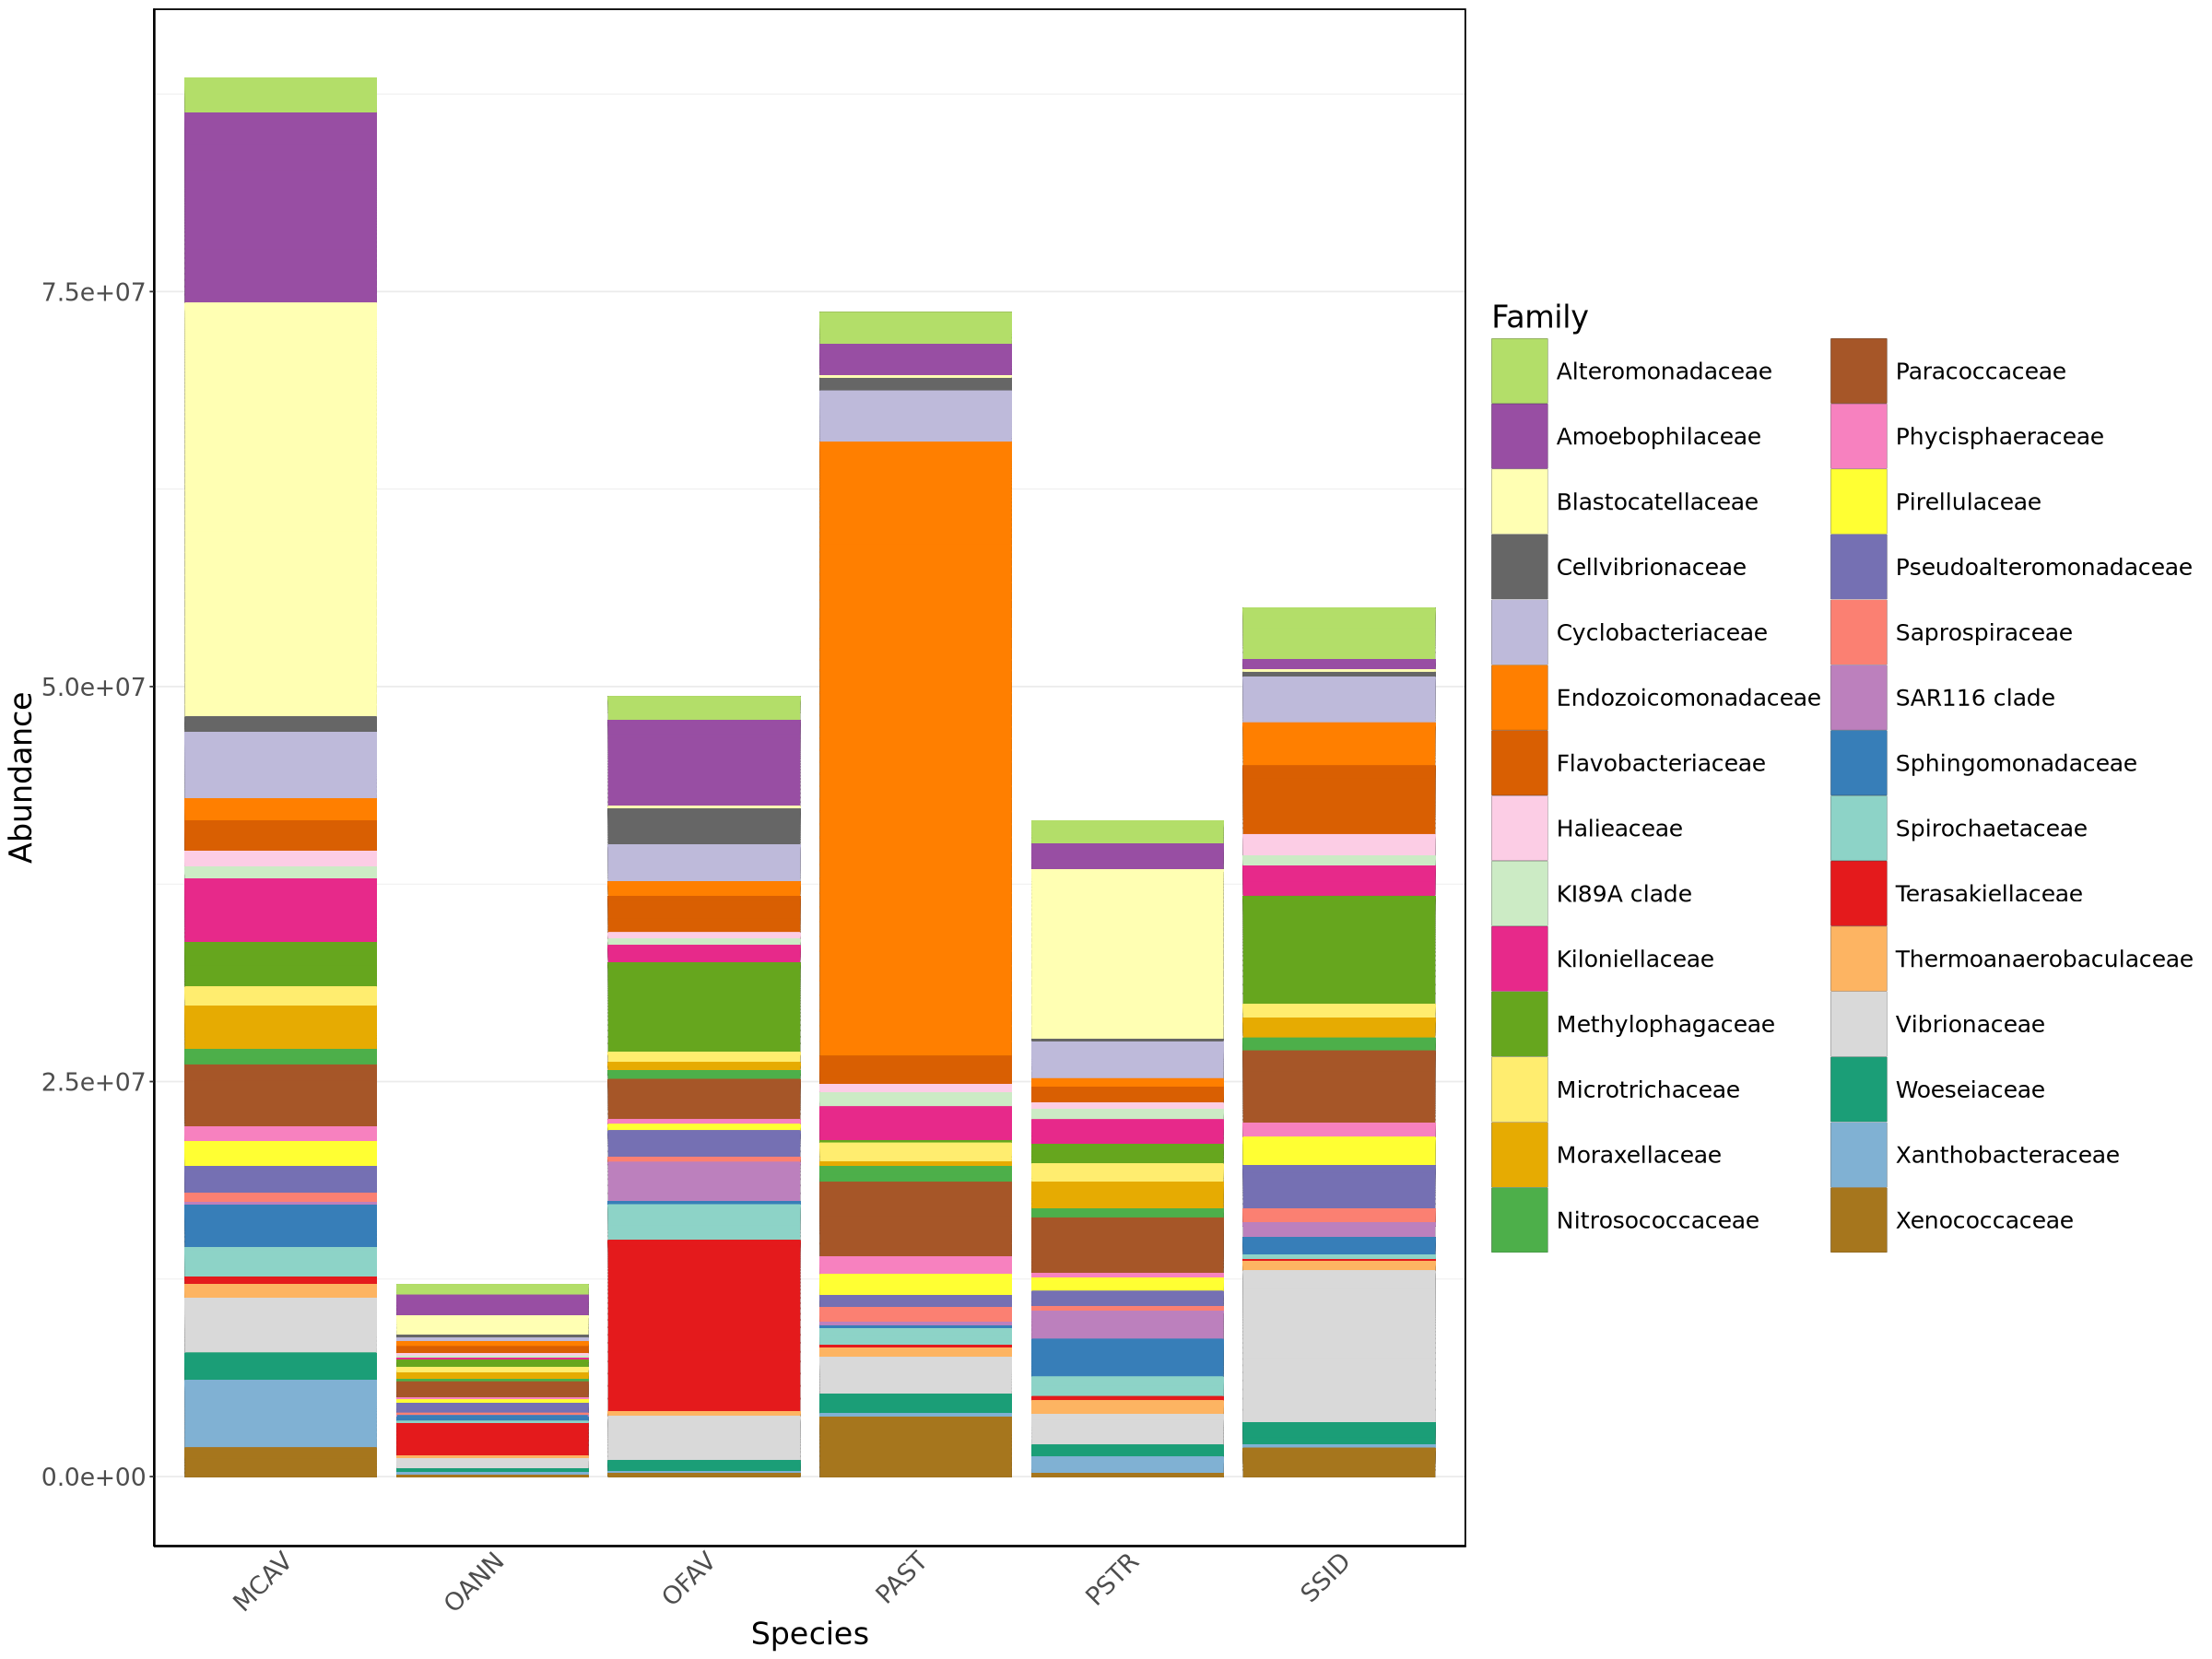

In [35]:
#plot
fam <- plot_bar(ps28_fam, x="Species", fill = "Family") +
  geom_bar(aes(color = Family, fill = Family), 
           stat = "identity", position = "stack") +
  scale_fill_manual(values = my_colors, drop = TRUE) +
  scale_color_manual(values = my_colors, drop = TRUE) +
  theme_bw() +
  theme(
    legend.position = "right",
      legend.title = element_text(size = 20),
  legend.text = element_text(size = 15),
  legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.5, "cm"),   # make them taller
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 20)
  )
guides(color = guide_legend(override.aes = list(size = 6))) 
fam

### isolate legend
- need ggpubr
- https://rpkgs.datanovia.com/ggpubr/reference/get_legend.html

## family plots for each species 
- facetted by colony

# How do the microbiomes of individual colonies change with exposure to stressors like heat and disease?
- P. asteroides seem to lose their endozoic communities after bleaching, and gain them back after recovery
- MCAV and PSTR (that did not contract SCTLD) seem to develop larger Blastocatallacae commuinities after disease outbreak

### past

<Guides[1] ggproto object>

colour : <GuideLegend>

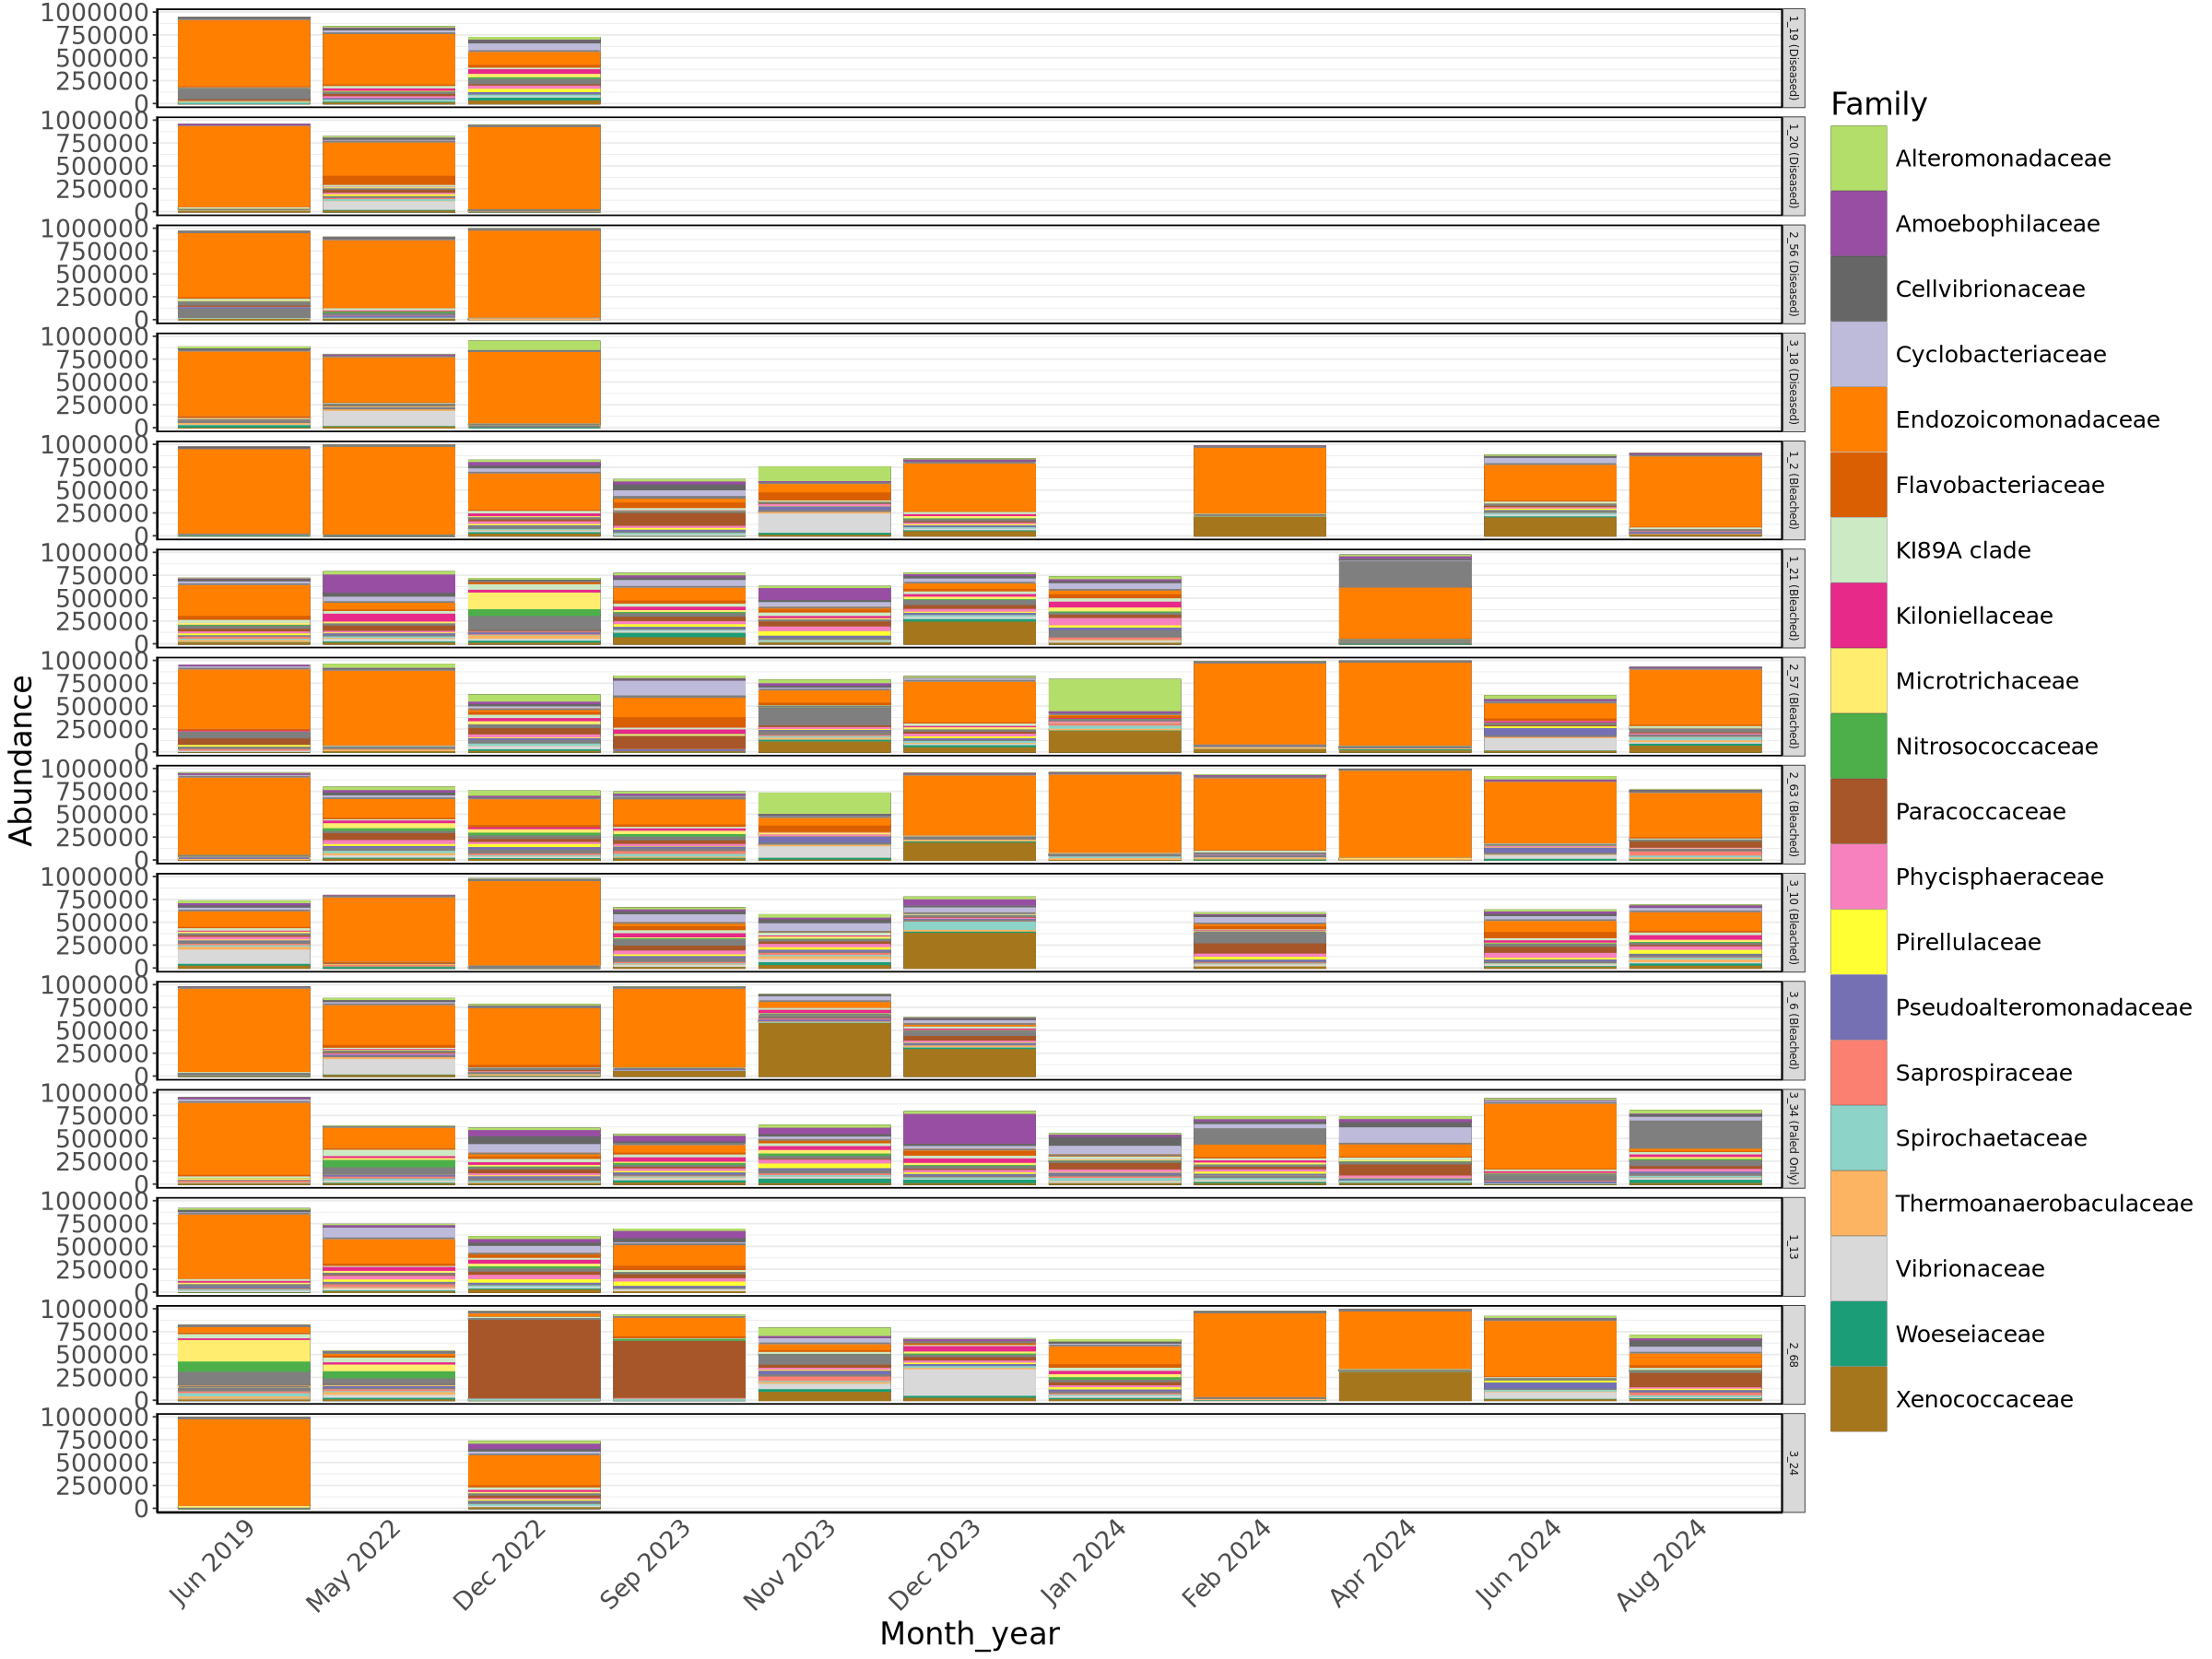

In [36]:
ps_past=tax_glom(ps_past, taxrank= "Family")

top25_past <- names(sort(taxa_sums(ps_past), decreasing=TRUE))[1:25] 
top25_past <- prune_taxa(top25_past, ps_past) 

#plot
past <- plot_bar(top25_past, x="Month_year", fill = "Family") +
  facet_wrap(colony_labeled ~., strip.position = "right", ncol = 1) +
  geom_bar(aes(color = Family, fill = Family), 
           stat = "identity", position = "stack") +
  scale_fill_manual(values = my_colors, drop = TRUE) +
  scale_color_manual(values = my_colors, drop = TRUE) +
  theme_bw() +
  theme(
    legend.position = "right",
      legend.title = element_text(size = 20),
  legend.text = element_text(size = 15),
  legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.5, "cm"),   # make them taller
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 20), 
           strip.text = element_text(size = 7) #facet size
  )
guides(color = guide_legend(override.aes = list(size = 6))) 
past

- **what disease did 1_19, 1_20, 2_56, and 3_18 have?**
- *these are non-immune samples, sankey plot can be found here* https://github.com/leahharper/SCTLD_demographics/blob/main/Figures/current/Fig%203.png
- 3_18 has since been sampled as healthy https://drive.google.com/drive/folders/1nSGHY2wvVjFv9pwx14g6OERhEeFM2LOz
- 2_56 was also H, Dis, H and now dead
- 1_19 and 1_20 conditions H, Disease, H, CLP, Dead

### figure notes
- The figure above shows us that P. asteroides microbiomes are changing temporarily after bleaching. For example: in Sep 2023 and before, most colonies had high relative abundances of endozoicomonas, whereas for bleached samples the endozoicomonas populations are decreased.
- We also see patterns of endozoicomonas recovery in P. asteroides colonies that recovered from bleaching.
- only one colony (3_34) exclusively paled and this one seemed to hold off on reintroducing endozoic and rediversified its bacterial community in Aug2024 (**potentially in preparation for the next heatwave?**)

### pstr

<Guides[1] ggproto object>

colour : <GuideLegend>

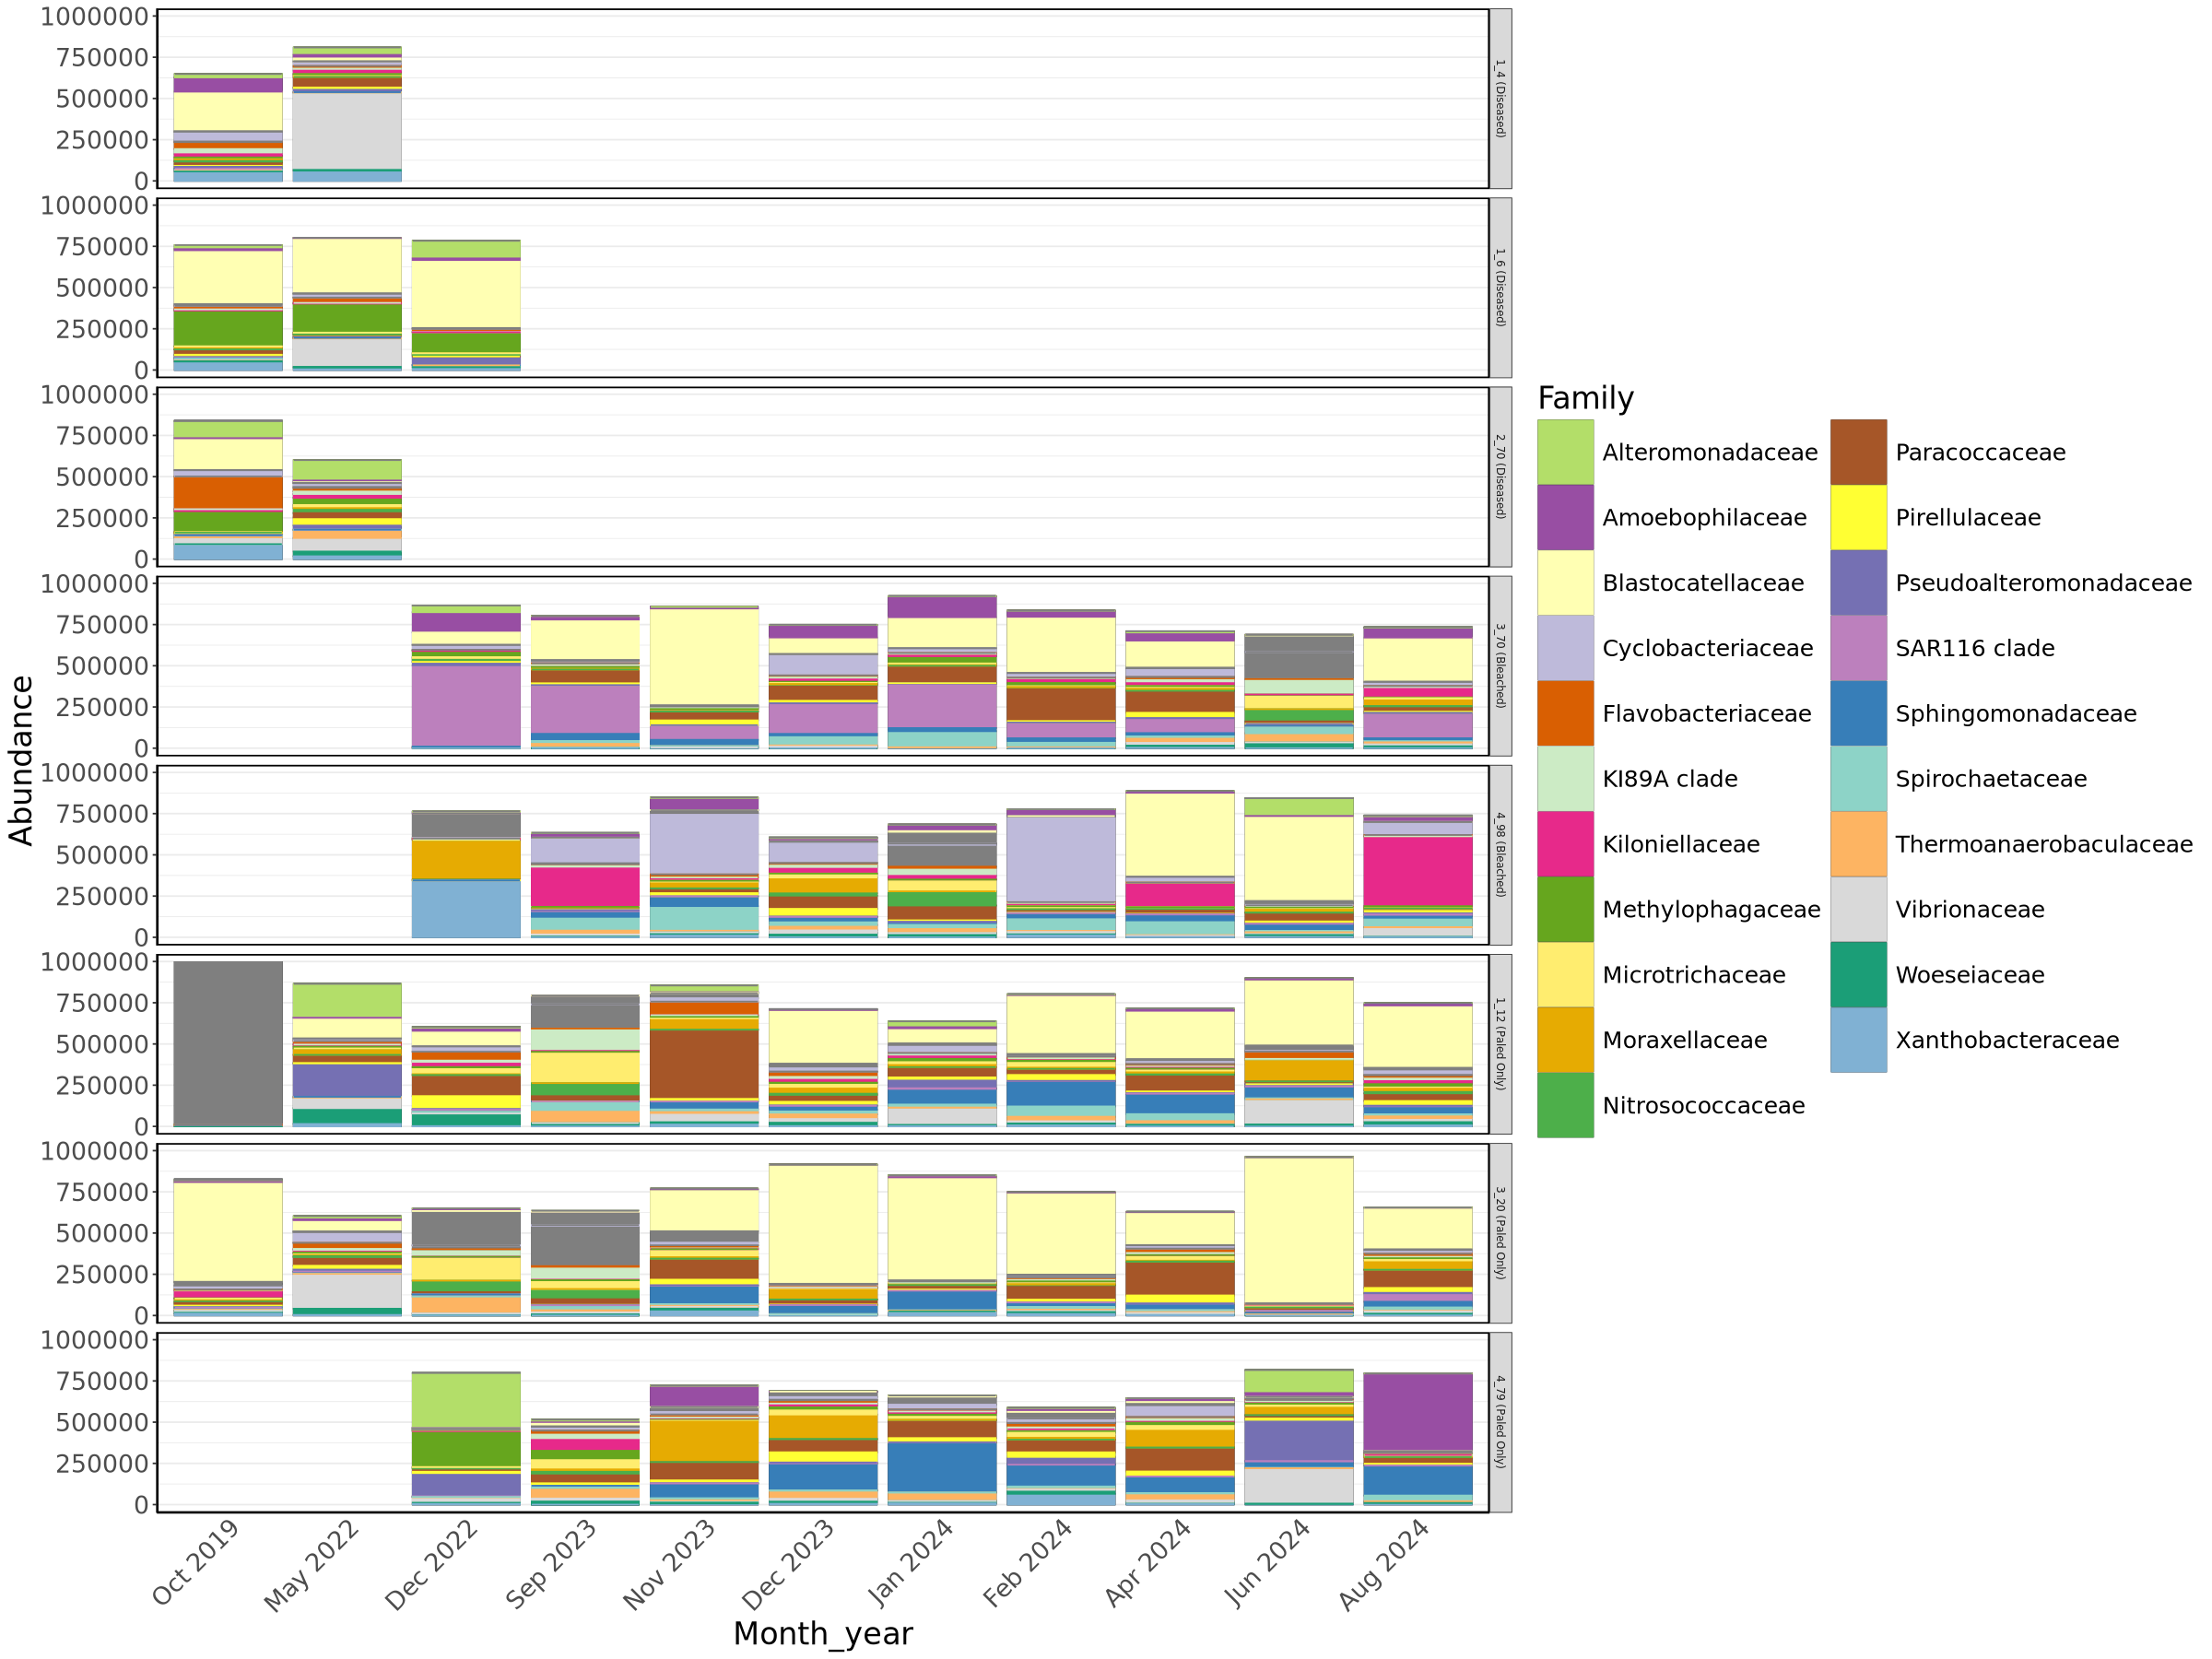

In [37]:
#reduce to top 50
fam_pstr=tax_glom(ps_pstr, taxrank= "Family")

top25_pstr <- names(sort(taxa_sums(fam_pstr), decreasing=TRUE))[1:25] 
fam25_pstr <- prune_taxa(top25_pstr, fam_pstr) 

#plot
fam_pstr <- plot_bar(fam25_pstr, x="Month_year", fill="Family") +
   facet_wrap(colony_labeled ~., strip.position = "right", ncol = 1) +
  geom_bar(aes(color = Family, fill = Family), 
           stat = "identity", position = "stack") +
  scale_fill_manual(values = my_colors, drop = TRUE) +
  scale_color_manual(values = my_colors, drop = TRUE) +
  theme_bw() +
  theme(
    legend.position = "right",
      legend.title = element_text(size = 20),
  legend.text = element_text(size = 15),
  legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.5, "cm"),   # make them taller
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 20),
                 strip.text = element_text(size = 7) #facet size
  )
guides(color = guide_legend(override.aes = list(size = 6))) 
fam_pstr

corrections made to this plot
- i had accidentally excluded Oct 2019 from the plots, so that date was showing up as NA
- colonies that were sampled as diseased_margin and diseased_tissue at one time point were being counted toward a colony sampled twice, but only showing up in the plot as one time point. to fix this I have temporaily removed Diseased_Margin samples from the original ps object **refer to line 42**

### figure notes 
- We may be seeing a reduction of microbiome community diversity in PSTR's after disease and bleaching
    - increase in blastocatellacea after Nov 2023
- absolutely NO endozoicomonas in PSTR
- there are no completely healthy PSTR's (all experienced some disease or color loss)
- after grouping the colonies into diseased, bleached, only_paled and healthy we can see that Alteromonadacae and Methylophagacae are primarily present in 2019 and 2022 (even in 4_79 which was never diseased and lost Altero and Methylo

### questions about this figure
- we see increased 16S diversity in Sept 2023, what month did our PSTR's bleach?
- Colony_data:
-  5 PSTR CLP in 092023
-  3 CLP, 2 CLB in 112023

### mcav

<Guides[1] ggproto object>

colour : <GuideLegend>

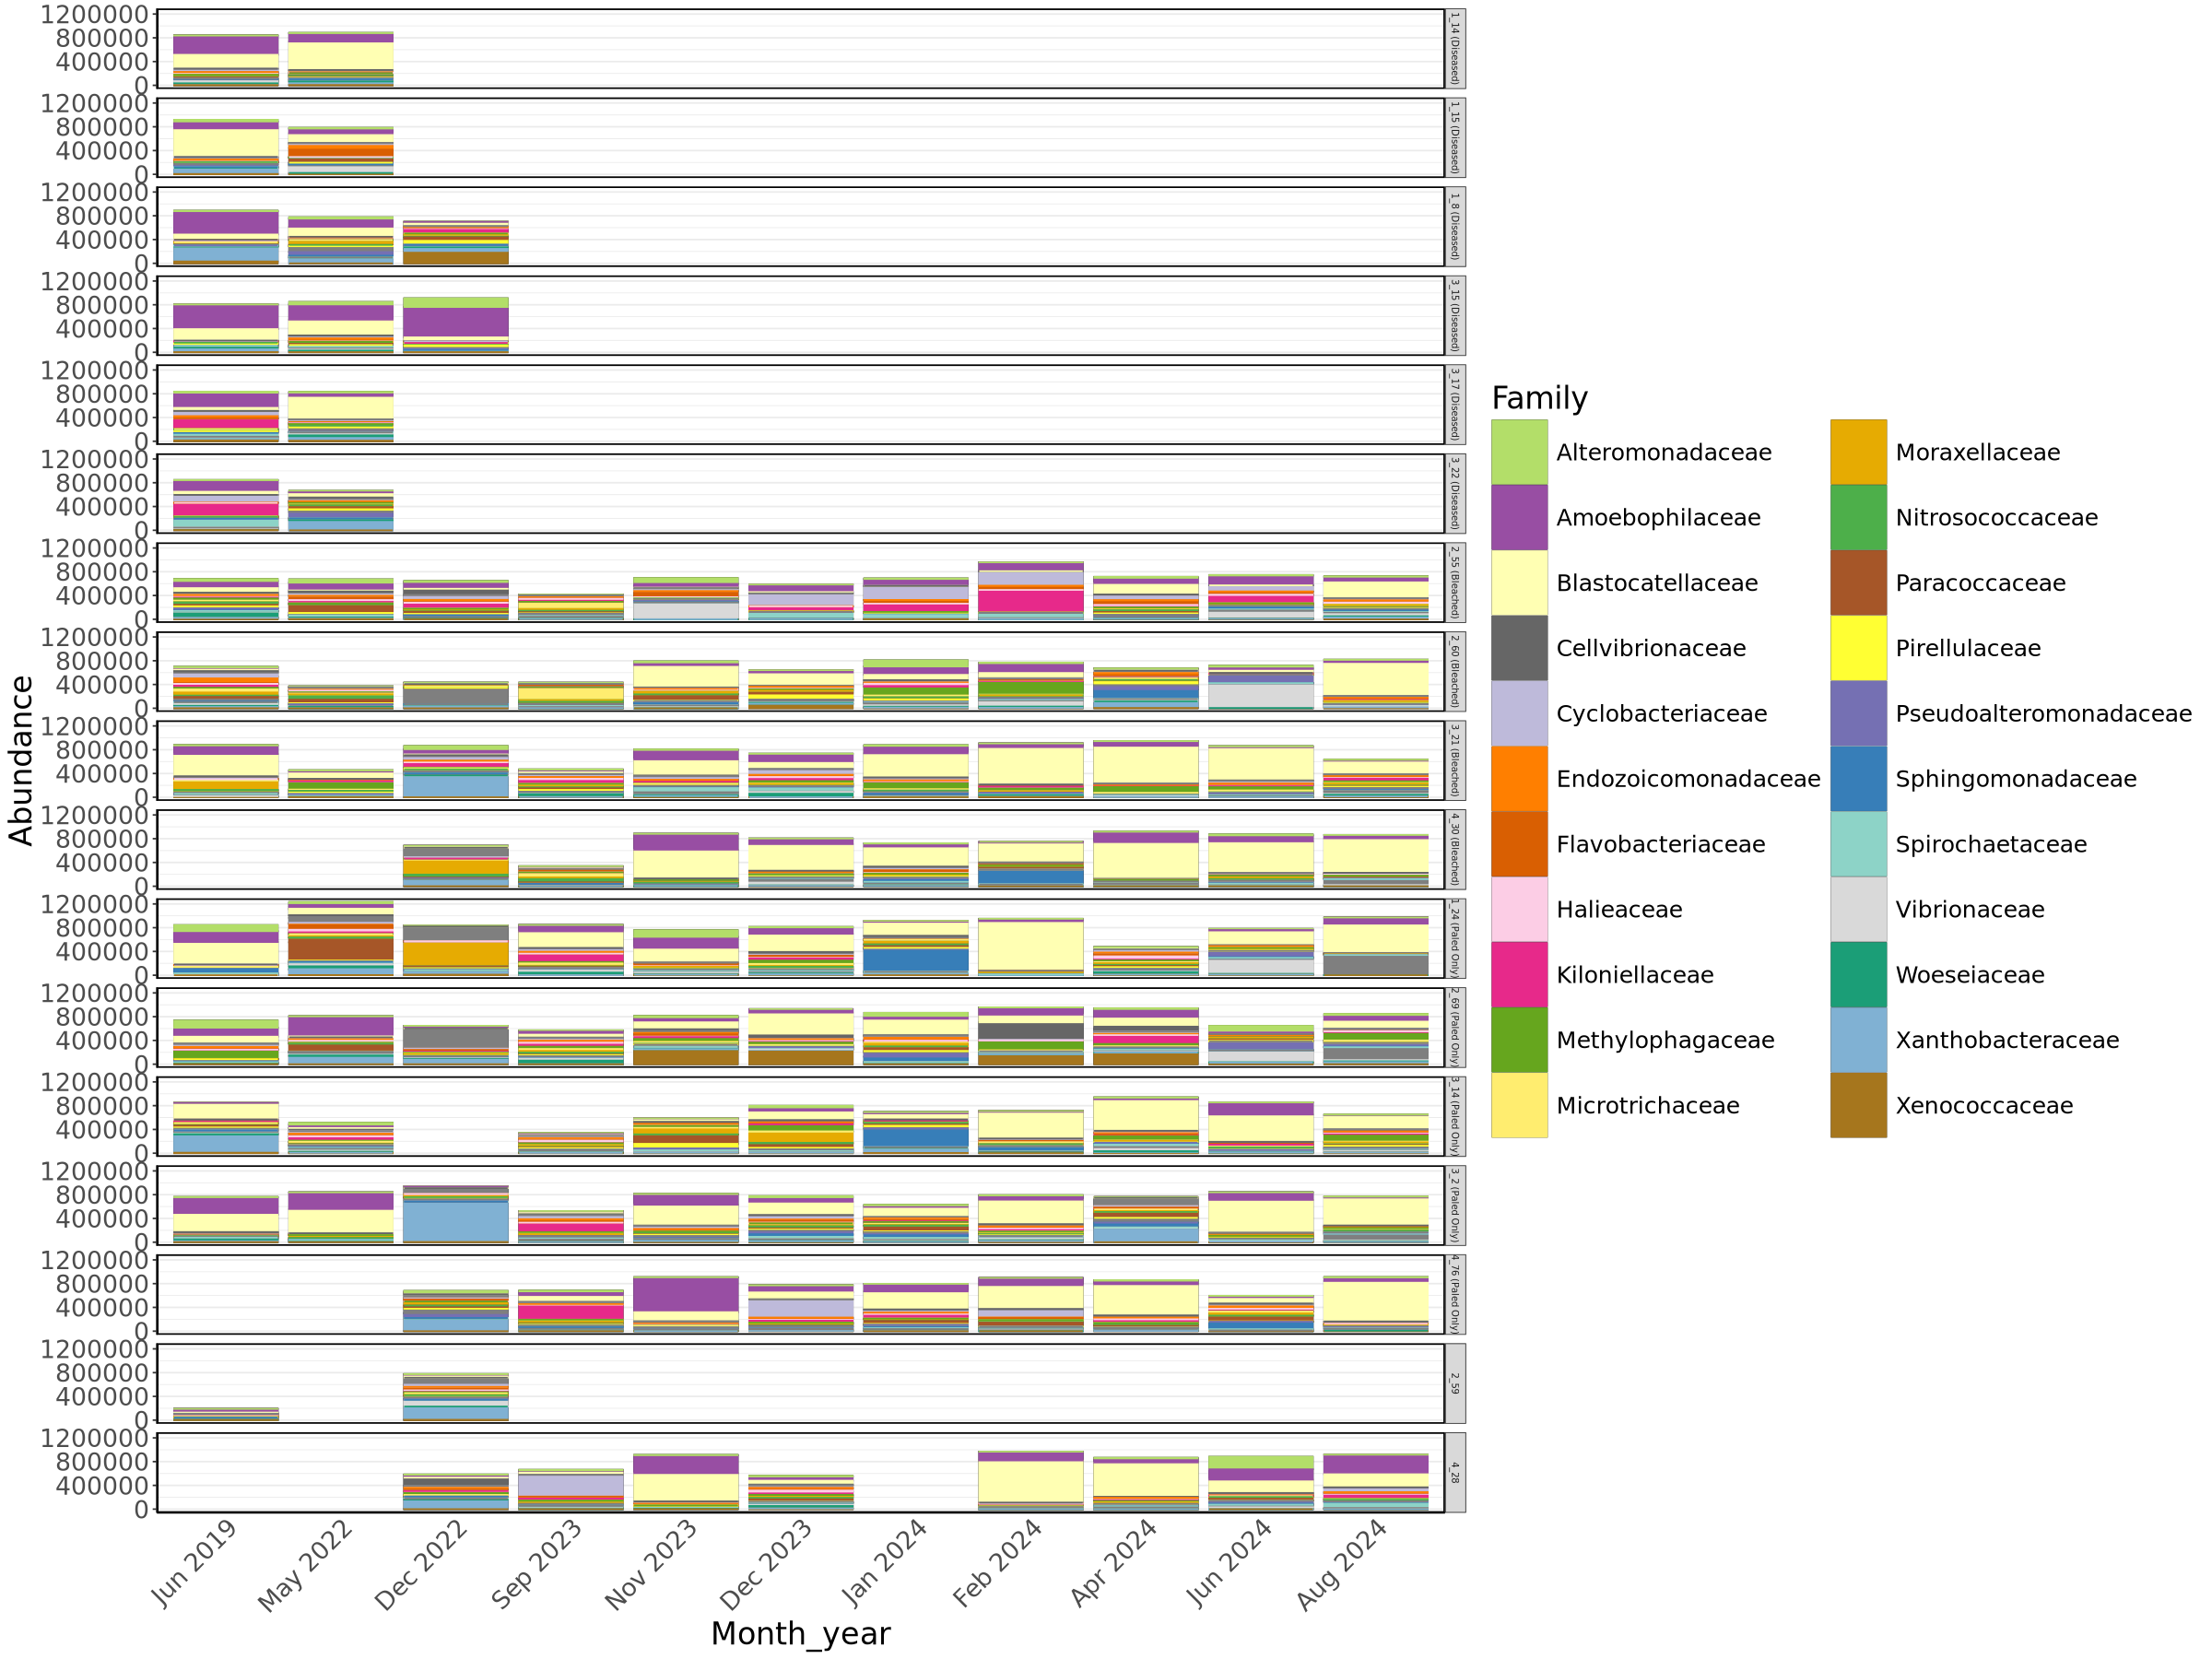

In [39]:
#reduce to top 50
fam_mcav=tax_glom(ps_mcav, taxrank= "Family")

top25_mcav <- names(sort(taxa_sums(fam_mcav), decreasing=TRUE))[1:25] 
top25_mcav <- prune_taxa(top25_mcav, fam_mcav) 

#plot
fam_mcav <- plot_bar(top25_mcav, x="Month_year", fill="Family") +
   facet_wrap(colony_labeled ~., strip.position = "right", ncol = 1) +
  geom_bar(aes(color = Family, fill = Family), 
           stat = "identity", position = "stack") +
  scale_fill_manual(values = my_colors, drop = TRUE) +
  scale_color_manual(values = my_colors, drop = TRUE) +
  theme_bw() +
  theme(
    legend.position = "right",
      legend.title = element_text(size = 20),
  legend.text = element_text(size = 15),
  legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.5, "cm"),   # make them taller
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
   text = element_text(size = 20),
         strip.text = element_text(size = 6) #facet size
  )
guides(color = guide_legend(override.aes = list(size = 6))) 
fam_mcav

corrections made to this plot
- MCAV colony 3_2 was listed as "Diseased_Other" in conditions so I changed the code to represent all Conditions="Dieased" should be counted as SCTLD **refer to line 55**

### figure notes
- MCAV colonies grouped by disease, bleached, only_paled, healthy
- Look at the changes in alpha diversity over time because it seems that MCAV microbiomes were more diverse before disease and bleaching
    - similar to PSTR, increase in blastocatallacae after bleaching

## look at species health status before removal of Diseased_Margin **line 42**

### past health status

Warning message in geom_text(aes(label = Family, fill = Family), position = position_stack(vjust = 0.5), :
“Ignoring unknown aesthetics: fill”


<Guides[1] ggproto object>

colour : <GuideLegend>

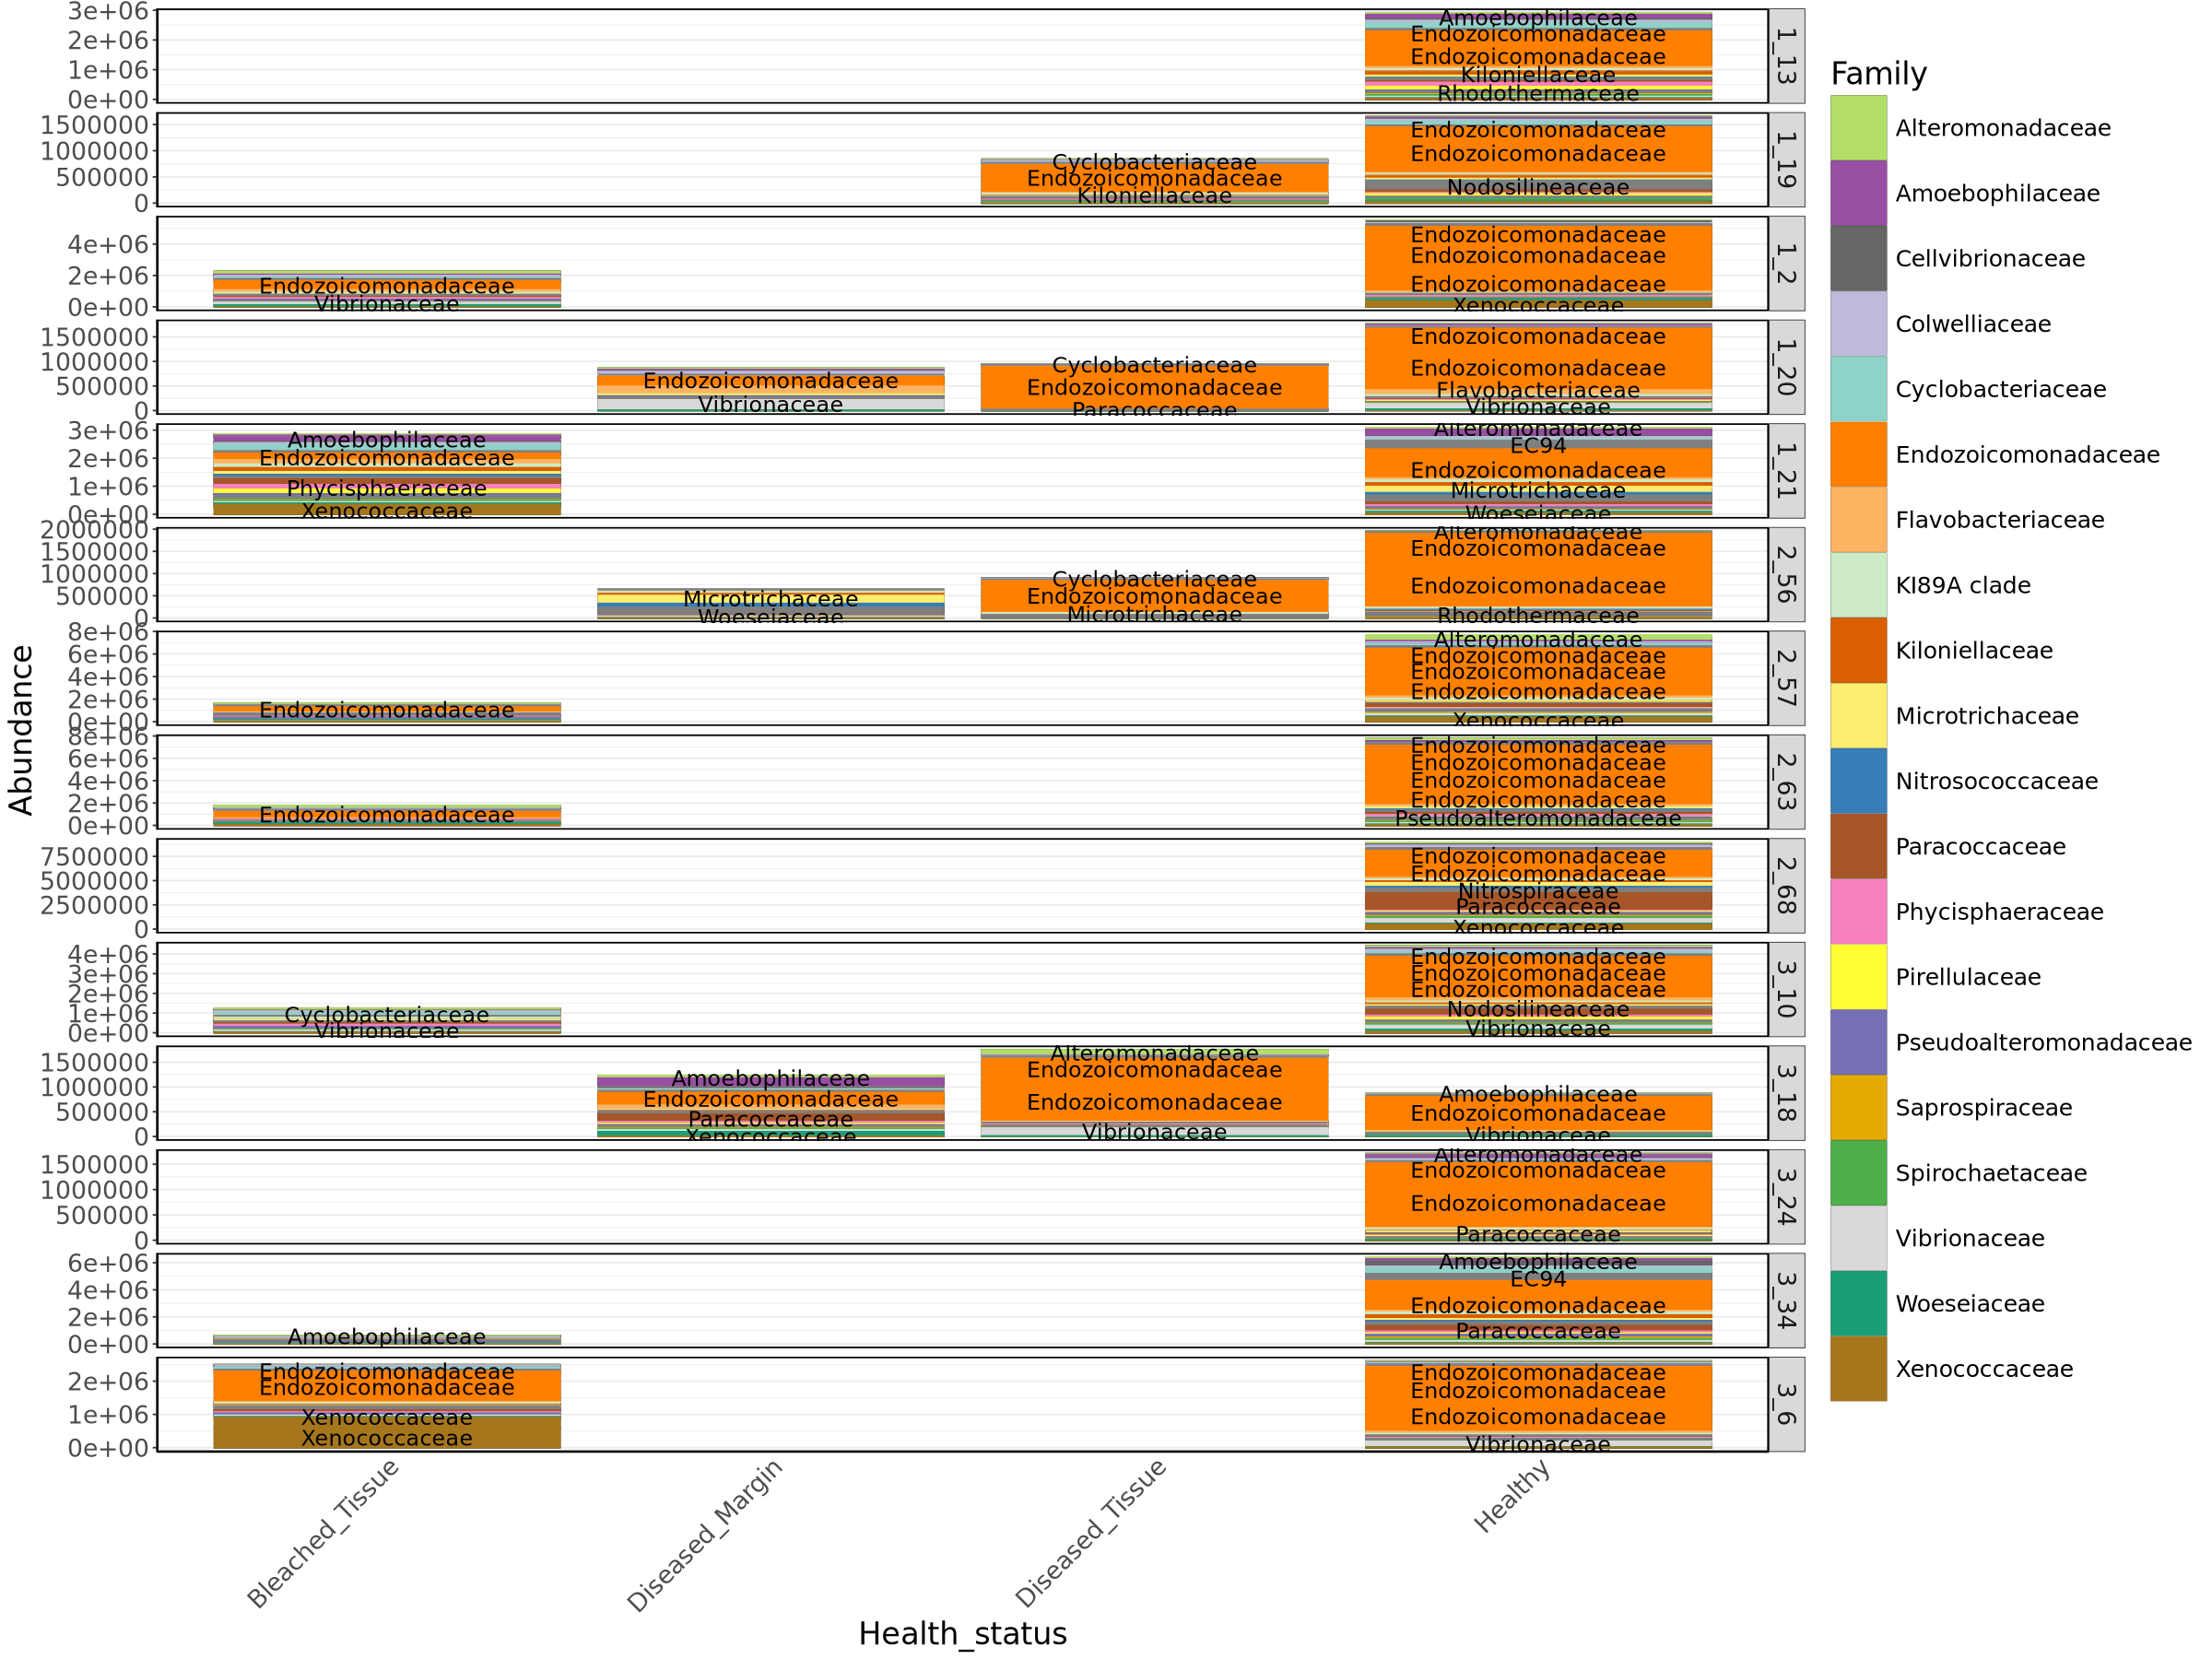

In [213]:
#plot
health_past <- plot_bar(top25_past, x="Health_status", fill="Family") +
   facet_wrap(colony ~., strip.position = "right", ncol = 1, scales = "free_y") +
  geom_bar(aes(color = Family, fill = Family), 
           stat = "identity", position = "stack") +
  geom_text(aes(label = Family, fill = Family),
            position = position_stack(vjust = 0.5),
            color = "black", size = 5, check_overlap = TRUE) +
  scale_fill_manual(values = my_colors, drop = TRUE) +
  scale_color_manual(values = my_colors, drop = TRUE) +
  theme_bw() +
  theme(
    legend.position = "right",
      legend.title = element_text(size = 20),
  legend.text = element_text(size = 15),
  legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.5, "cm"),   # make them taller
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 20)
  )
guides(color = guide_legend(override.aes = list(size = 6))) 
health_past

### mcavs health status

Warning message in geom_text(aes(label = Family, fill = Family), position = position_stack(vjust = 0.5), :
“Ignoring unknown aesthetics: fill”


<Guides[1] ggproto object>

colour : <GuideLegend>

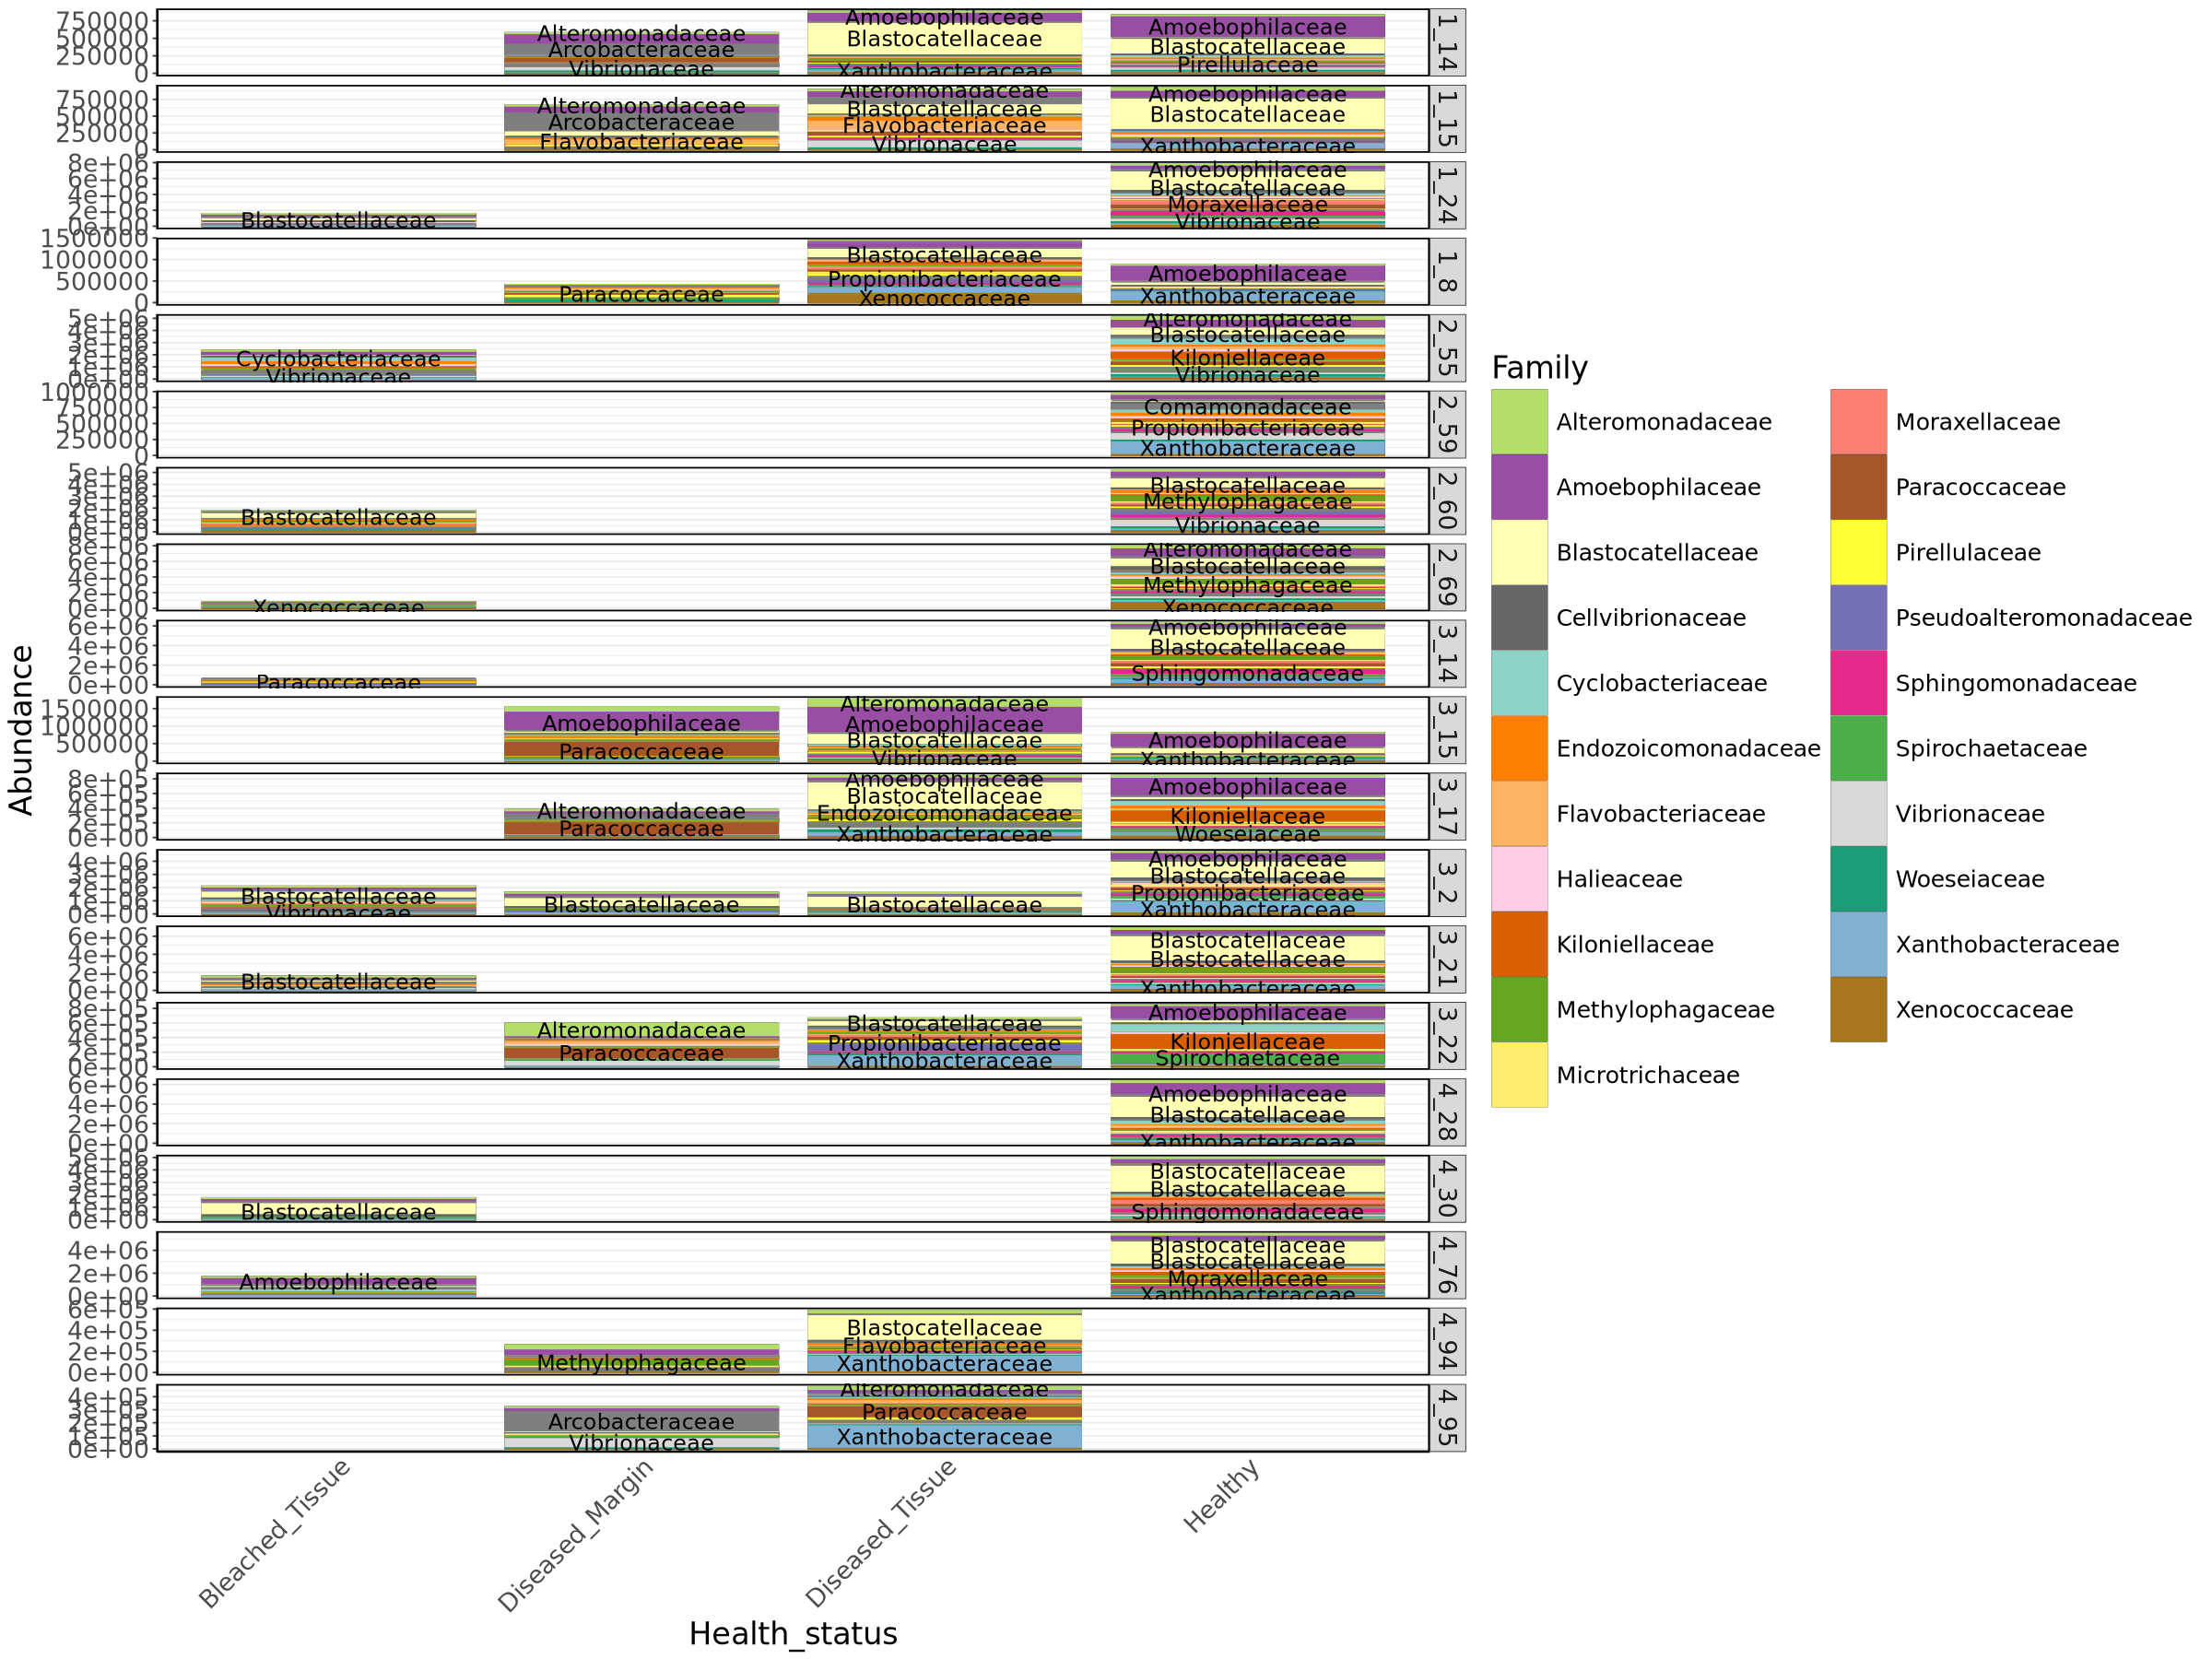

In [215]:

#plot
health_mcav <- plot_bar(top25_mcav, x="Health_status", fill="Family") +
   facet_wrap(colony ~., strip.position = "right", ncol = 1, scales = "free_y") +
  geom_bar(aes(color = Family, fill = Family), 
           stat = "identity", position = "stack") +
  geom_text(aes(label = Family, fill = Family),
            position = position_stack(vjust = 0.5),
            color = "black", size = 5, check_overlap = TRUE) +
  scale_fill_manual(values = my_colors, drop = TRUE) +
  scale_color_manual(values = my_colors, drop = TRUE) +
  theme_bw() +
  theme(
    legend.position = "right",
      legend.title = element_text(size = 20),
  legend.text = element_text(size = 15),
  legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.5, "cm"),   # make them taller
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 20)
  )
guides(color = guide_legend(override.aes = list(size = 6))) 
health_mcav

### pstr health status

Warning message in geom_text(aes(label = Family, fill = Family), position = position_stack(vjust = 0.5), :
“Ignoring unknown aesthetics: fill”


<Guides[1] ggproto object>

colour : <GuideLegend>

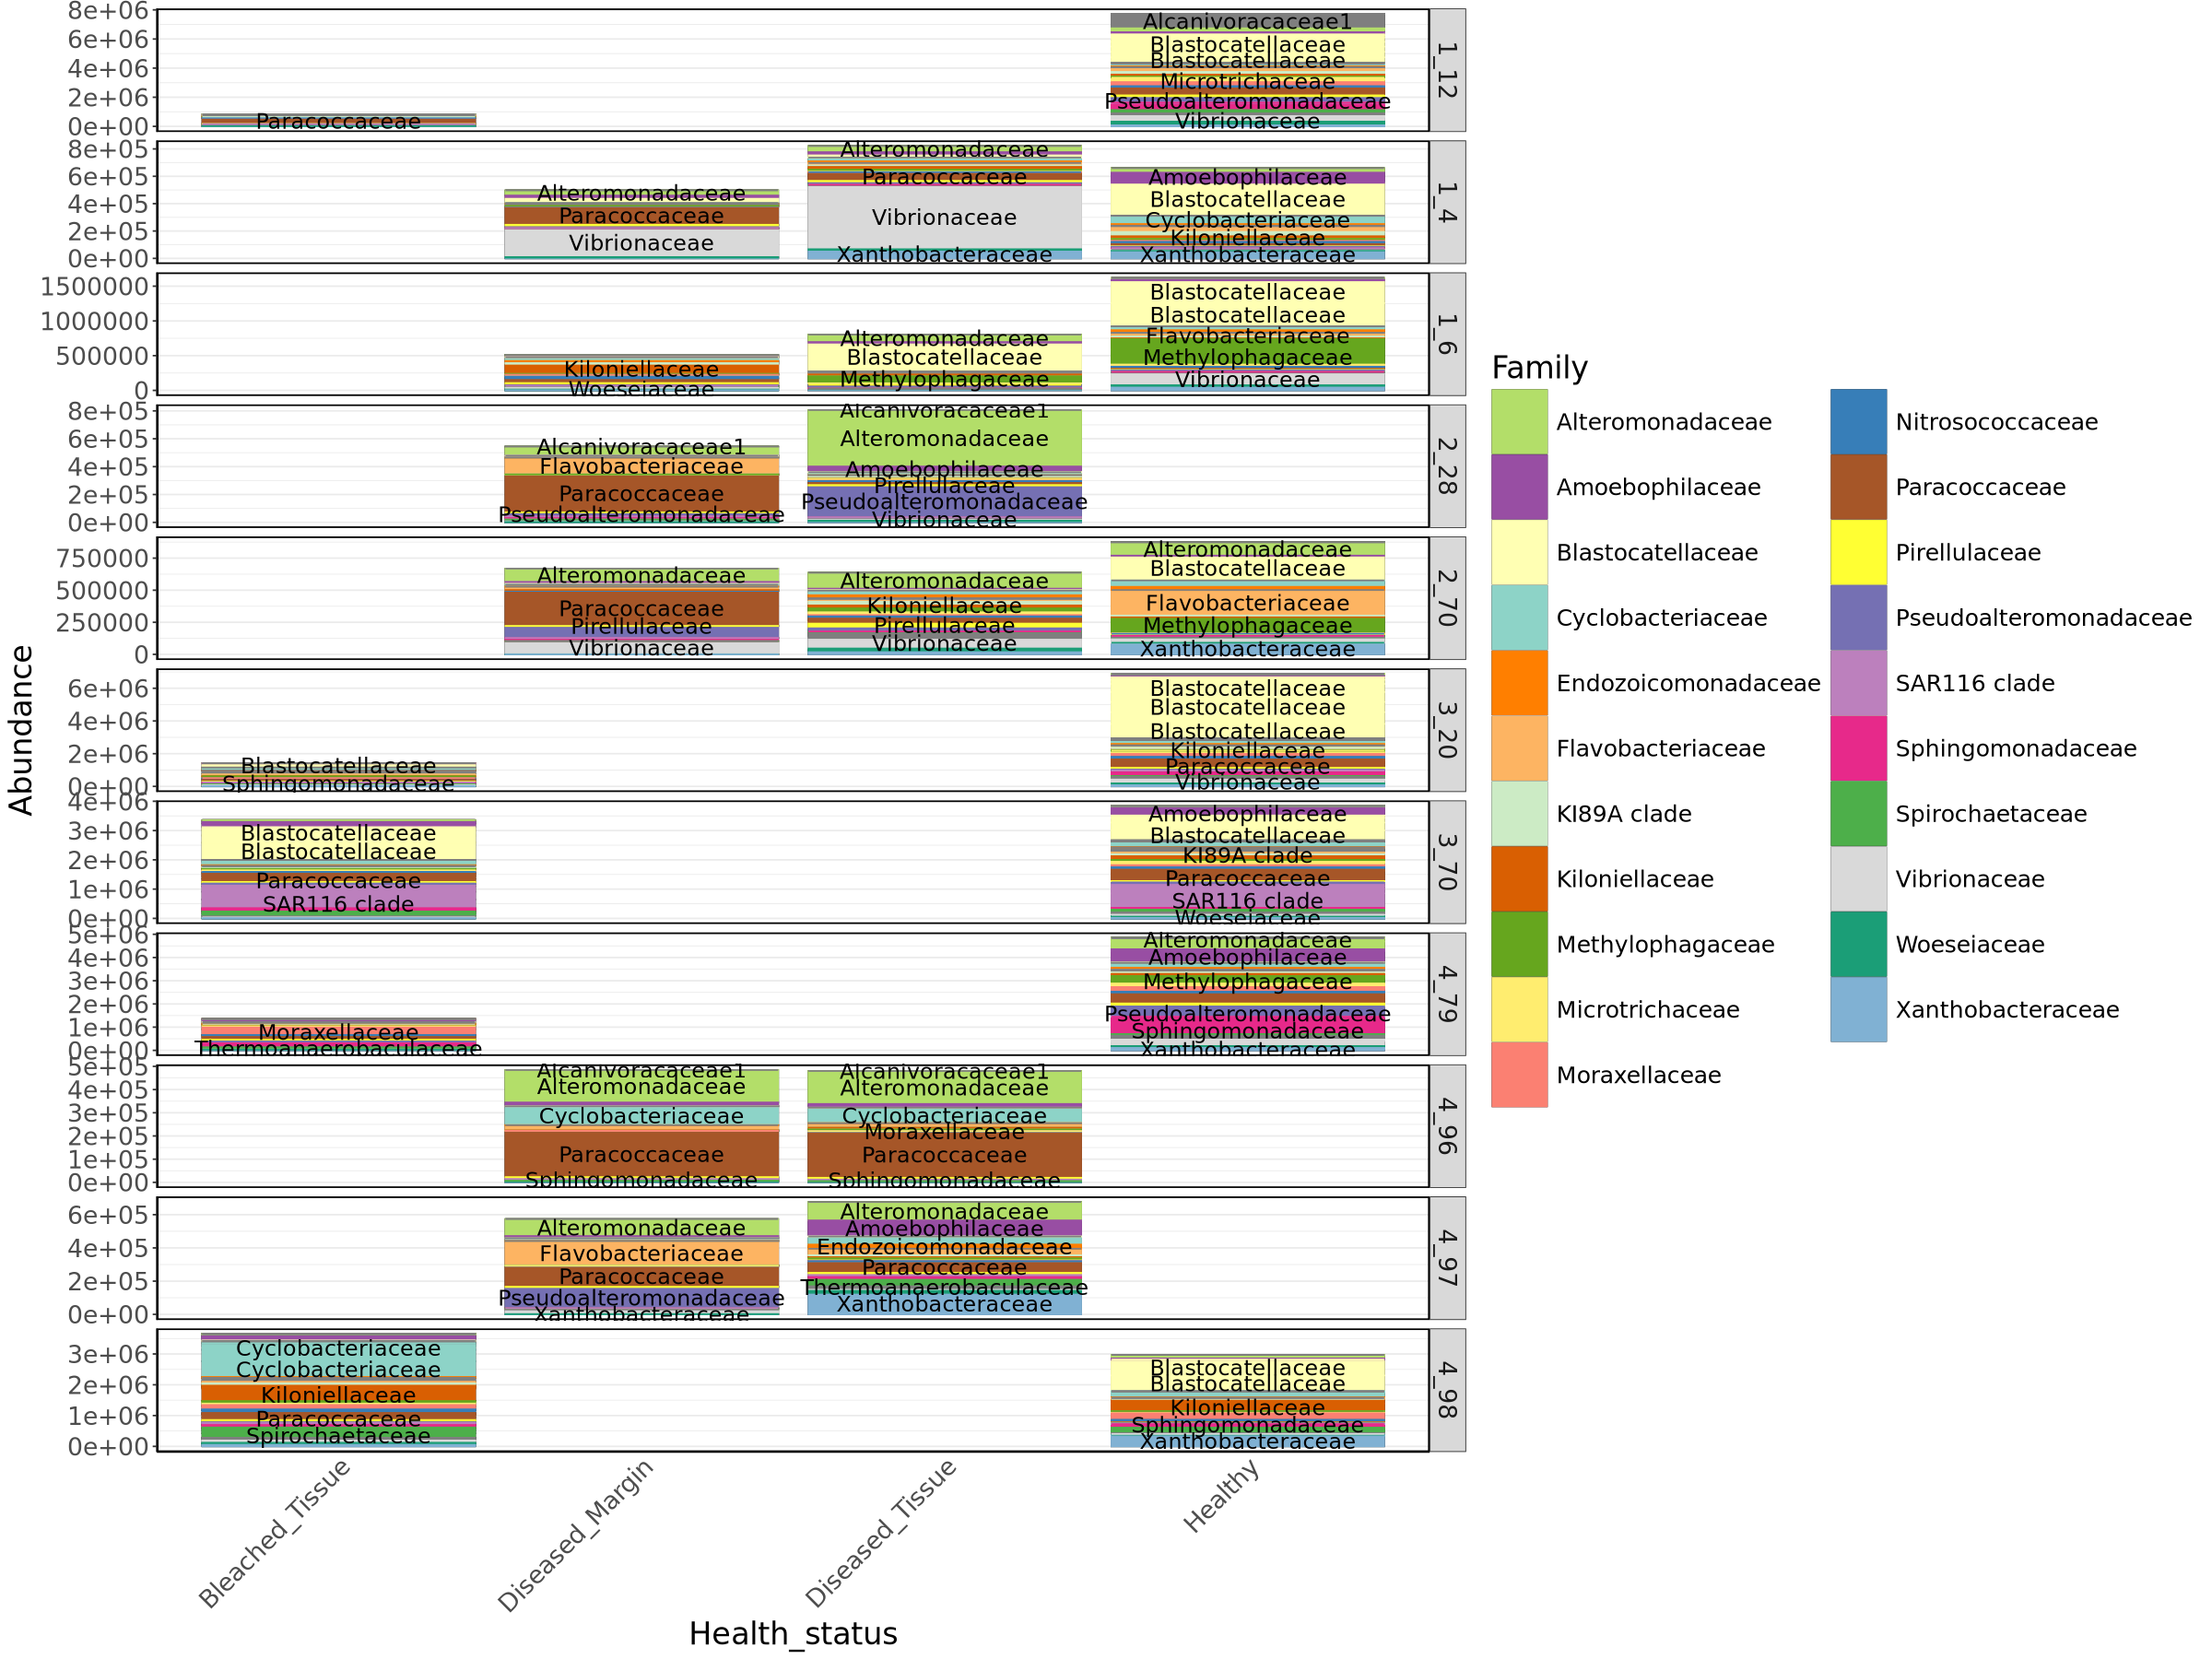

In [217]:
#plot
health_pstr <- plot_bar(fam25_pstr, x="Health_status", fill="Family") +
   facet_wrap(colony ~., strip.position = "right", ncol = 1, scales = "free_y") +
  geom_bar(aes(color = Family, fill = Family), 
           stat = "identity", position = "stack") +
  geom_text(aes(label = Family, fill = Family),
            position = position_stack(vjust = 0.5),
            color = "black", size = 5, check_overlap = TRUE) +
  scale_fill_manual(values = my_colors, drop = TRUE) +
  scale_color_manual(values = my_colors, drop = TRUE) +
  theme_bw() +
  theme(
    legend.position = "right",
      legend.title = element_text(size = 20),
  legend.text = element_text(size = 15),
  legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.5, "cm"),   # make them taller
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 20)
  )
guides(color = guide_legend(override.aes = list(size = 6))) 
health_pstr